#### Imports


In [28]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import re
import os 
from sklearn.model_selection import train_test_split

print("All impoorts successful")

All impoorts successful


In [15]:
# define file path 
RAW_DATA_PATH = "../data/raw/SQLiV3.csv"
PROCESSED_DIR = "../data/processed/sqliv3_clean.csv"
TRAIN_SPLIT_PATH = "../data/processed/train_split.csv"
TEST_SPLIT_PATH = "../data/processed/test_split.csv"

In [33]:
# load the raw SQLiv3 dataset 

df= pd.read_csv(RAW_DATA_PATH, encoding='utf-8') #read dataset
df.head(10)

,Sentence,Label,Unnamed: 2,Unnamed: 3
0,""" or pg_sleep ( __TIME__ ) --",1,NaN,NaN
1,create user name identified by pass123 tempora...,NaN,1,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1,NaN,NaN
3,select * from users where id = '1' or @ @1 ...,1,NaN,NaN
4,"select * from users where id = 1 or 1#"" ( ...",1,NaN,NaN
5,select name from syscolumns where id = ...,1,NaN,NaN
6,select * from users where id = 1 +$+ or 1 =...,1,NaN,NaN
7,"1; ( load_file ( char ( 47,101,116,99,47...",1,NaN,NaN
8,select * from users where id = '1' or ||/1 ...,1,NaN,NaN
9,select * from users where id = '1' or \.<\ ...,1,NaN,NaN


In [34]:
#remove unused columns 
del df['Unnamed: 2']

del df['Unnamed: 3']

print("shape:", df.shape)

df.head()


shape: (30919, 2)


,Sentence,Label
0,""" or pg_sleep ( __TIME__ ) --",1
1,create user name identified by pass123 tempora...,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1


In [35]:
# Cell 5 - Inspect the dataset structure


print("----------------------------------------------------")
df.info()
print("----------------------------------------------------")
print()
df['Label'].describe()

----------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 30919 entries, 0 to 30918
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Sentence  30904 non-null  str  
 1   Label     30664 non-null  str  
dtypes: str(2)
memory usage: 483.2 KB
----------------------------------------------------



count     30664
unique       42
top           0
freq      19268
Name: Label, dtype: object

##### Process NaN values 

In [36]:
#count NaN labels values 

print(f"NaN values in Label column:{df['Label'].isna().sum()}")

NaN values in Label column:255


In [37]:
# drop NaN rows 

df = df.dropna()
print(f"shape:{df.shape}")

shape:(30649, 2)


##### Fixing the target labels 

In [38]:
#show unique values before fixing 

unique_label =pd.unique(df['Label'])

print("Unique values in Label column:")

print()

for l in unique_label:
  print(repr(l))

Unique values in Label column:

'1'
'SELECT *'
' --'
' desc users'
' OR'
"waitfor delay '0:0:__TIME__'--"
' drop table temp --'
'0'
' grant resource to name'
' EXEC SelectAllCustomers'
' /*Select all the columns of all the records in the Customers table:*/'
'*/'
' CREATE VIEW [Products Above Average Price] AS'
' CREATE OR REPLACE VIEW view_name AS'
' DROP TABLE Suppliers'
' CREATE PROCEDURE SelectAllCustomers AS'
'  EXEC SelectAllCustomers'
" DELETE FROM Customers  WHERE CustomerName = 'Alfreds Futterkiste'"
' CREATE OR REPLACE VIEW [Brazil Customers] AS'
'  SELECT * FROM CustomersLIMIT 3'
'SELECT * FROM Customers'
' SELECT TOP 50 PERCENT * FROM Customers'
' SELECT * FROM CustomersFETCH FIRST 50 PERCENT ROWS ONLY'
'SELECT TOP 3 * FROM Customers'
' SELECT * FROM Customers'
'SELECT SUM ( Quantity ) '
' SELECT column_name ( s ) '
' SELECT City FROM Customers'


In [39]:
# fix the Label column 

df = df.drop(df[(df['Label'] !='0') & (df['Label'] != '1')].index)

df['Label']= df['Label'].astype('int')

df.info()

<class 'pandas.DataFrame'>
Index: 30609 entries, 0 to 30918
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Sentence  30609 non-null  str  
 1   Label     30609 non-null  int64
dtypes: int64(1), str(1)
memory usage: 717.4 KB


In [40]:
# count malicious and benign samples 

print("Malacious samples:")
print(df[df['Label']==1].count())

print()

print("Benign smaples:")
print(df[df['Label']==0].count())

Malacious samples:
Sentence    11341
Label       11341
dtype: int64

Benign smaples:
Sentence    19268
Label       19268
dtype: int64


##### Label Distribution 

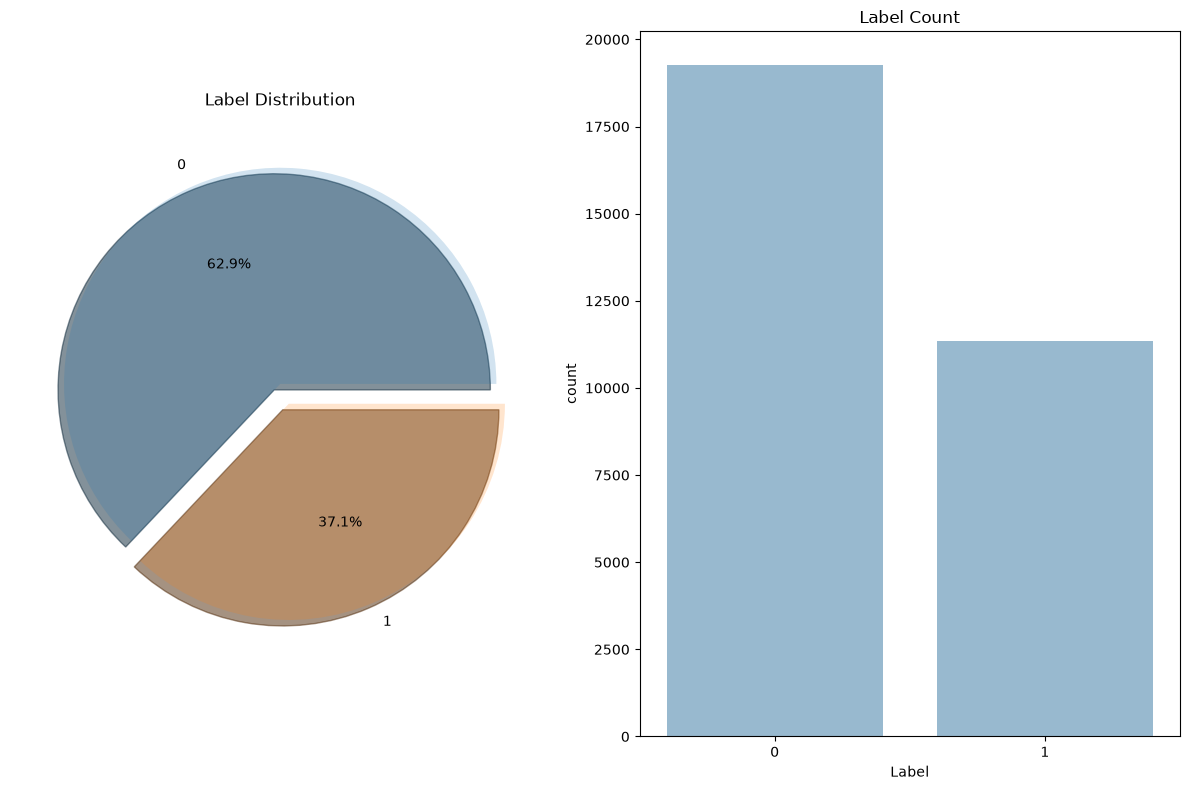

Chart saved


In [ ]:
# Visualise label distribution

f, ax = plt.subplots(1, 2, figsize=(12, 8))

# Pie chart
df['Label'].value_counts().plot.pie(
    explode=[0, 0.1],
    autopct='%1.1f%%',
    ax=ax[0],
    shadow=True,
    wedgeprops={'alpha': 0.2}
)
ax[0].set_title('Label Distribution')
ax[0].set_ylabel('')

# Bar chart
sns.countplot(x='Label', data=df, ax=ax[1], alpha=0.5)
ax[1].set_title('Label Count')

plt.tight_layout()
plt.savefig('../results/figures/label_distribution.png', dpi=150)
plt.show()

print("Chart saved")